# Task 5 (Player Style) — K-Means song song trên 3 phiên bản dữ liệu

**Input:** `player_X_unscaled.csv`, `player_X_standard_scaled.csv`, `player_X_robust_scaled.csv` (output Task 4, 1016 cầu thủ × 29 feature).

**Mục tiêu:** giống hệt phương pháp luận đã dùng ở bài Shot Zone — chạy K-Means qua nhiều k, xác định k tối ưu bằng Elbow/Silhouette/Gap Statistic, so sánh cấu trúc cụm giữa 3 phiên bản bằng ARI. Điểm khác biệt: dữ liệu cầu thủ có **29 feature** (nhiều hơn 9 feature ở bài shot) — không gian nhiều chiều hơn có thể ảnh hưởng đến hành vi của Gap Statistic, sẽ thấy rõ ở mục 5.3.


## 5.0 — Setup & load dữ liệu

In [44]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

DATA_DIR = "/kaggle/working"

FEATURE_COLS = [
    "shots_p90", "np_goals_p90", "avg_shot_distance", "dribbles_p90", "dribble_success_rate",
    "touches_p90", "touches_in_box_p90", "passes_p90", "pass_completion_pct", "key_passes_p90",
    "assists_p90", "crosses_p90", "through_balls_p90", "long_balls_p90", "avg_pass_length",
    "pressures_p90", "tackles_p90", "tackle_success_rate", "interceptions_p90",
    "interception_success_rate", "ball_recoveries_p90", "clearances_p90", "aerial_won_p90",
    "fouls_committed_p90", "fouls_won_p90", "avg_location_x", "avg_location_y",
    "std_location_x", "std_location_y",
]

raw_frames = {
    "Unscaled": pd.read_csv(f"{DATA_DIR}/player_X_unscaled.csv", encoding="utf-8-sig"),
    "StandardScaler": pd.read_csv(f"{DATA_DIR}/player_X_standard_scaled.csv", encoding="utf-8-sig"),
    "RobustScaler": pd.read_csv(f"{DATA_DIR}/player_X_robust_scaled.csv", encoding="utf-8-sig"),
}

id_df = raw_frames["Unscaled"][["player_id", "player_name", "primary_team",
                                 "competitions_played", "n_matches_played", "total_minutes_played"]].copy()

X_versions = {name: df[FEATURE_COLS].values for name, df in raw_frames.items()}
for name, X in X_versions.items():
    print(name, X.shape)


Unscaled (1016, 29)
StandardScaler (1016, 29)
RobustScaler (1016, 29)


## 5.1 — Elbow Method (song song 3 phiên bản)

In [45]:
K_RANGE = list(range(2, 11))


def kneedle_elbow(k_values, values):
    k = np.array(k_values, dtype=float)
    y = np.array(values, dtype=float)
    k_norm = (k - k.min()) / (k.max() - k.min())
    y_norm = (y - y.min()) / (y.max() - y.min())
    x1, y1 = k_norm[0], y_norm[0]
    x2, y2 = k_norm[-1], y_norm[-1]
    num = np.abs((y2 - y1) * k_norm - (x2 - x1) * y_norm + x2 * y1 - y2 * x1)
    den = np.sqrt((y2 - y1) ** 2 + (x2 - x1) ** 2)
    dist = num / den
    idx = np.argmax(dist)
    return int(k[idx])


inertia_results = {}
for name, X in X_versions.items():
    inertias = []
    for k in K_RANGE:
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        km.fit(X)
        inertias.append(km.inertia_)
    inertia_results[name] = inertias

elbow_k = {name: kneedle_elbow(K_RANGE, vals) for name, vals in inertia_results.items()}
print("Elbow k (kneedle):", elbow_k)


Elbow k (kneedle): {'Unscaled': 5, 'StandardScaler': 5, 'RobustScaler': 5}


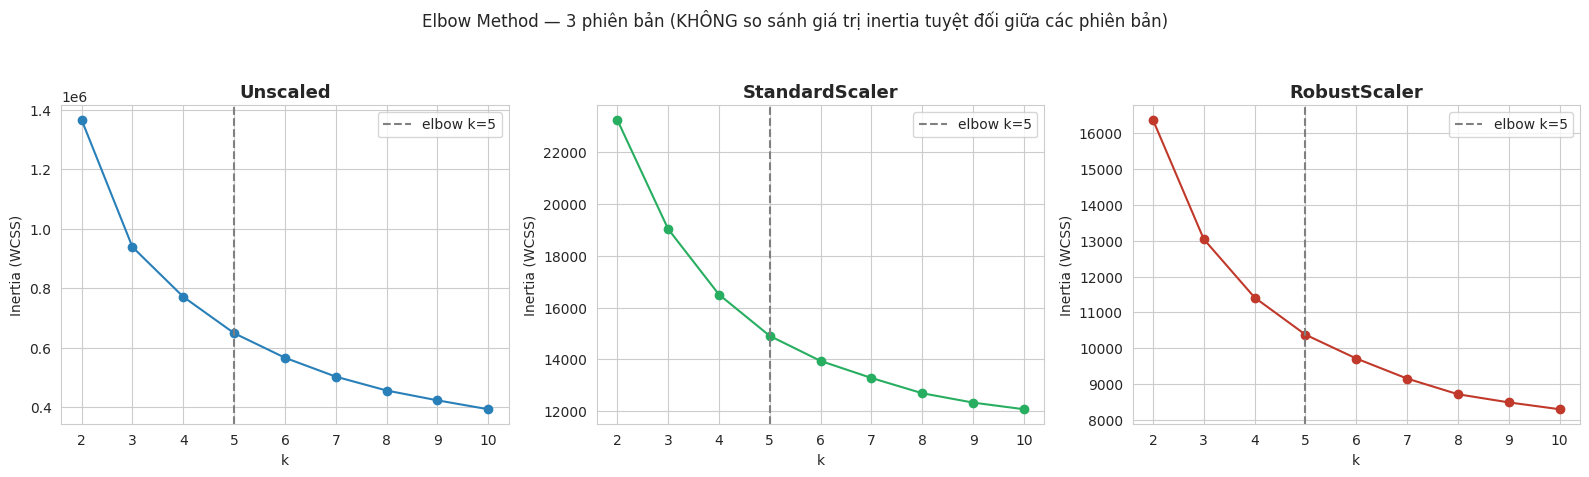

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True)
colors = {"Unscaled": "#2980b9", "StandardScaler": "#27ae60", "RobustScaler": "#c0392b"}

for ax, name in zip(axes, X_versions.keys()):
    ax.plot(K_RANGE, inertia_results[name], marker="o", color=colors[name])
    ax.axvline(elbow_k[name], linestyle="--", color="gray", label=f"elbow k={elbow_k[name]}")
    ax.set_title(name)
    ax.set_xlabel("k")
    ax.set_ylabel("Inertia (WCSS)")
    ax.legend()

plt.suptitle("Elbow Method — 3 phiên bản (KHÔNG so sánh giá trị inertia tuyệt đối giữa các phiên bản)", y=1.05)
plt.tight_layout()
plt.show()


Giống bài Shot Zone, cả 3 phiên bản đều cho **k=5** theo kneedle heuristic — Elbow tiếp tục cho thấy ít nhạy với việc scaling hơn Silhouette/Gap ở mục sau.

## 5.2 — Silhouette Score (song song 3 phiên bản)

In [47]:
silhouette_results = {}
for name, X in X_versions.items():
    sils = []
    for k in K_RANGE:
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        labels = km.fit_predict(X)
        sils.append(silhouette_score(X, labels))
    silhouette_results[name] = sils

best_k_silhouette = {name: K_RANGE[int(np.argmax(vals))] for name, vals in silhouette_results.items()}
print("Best k theo Silhouette:", best_k_silhouette)


Best k theo Silhouette: {'Unscaled': 3, 'StandardScaler': 3, 'RobustScaler': 2}


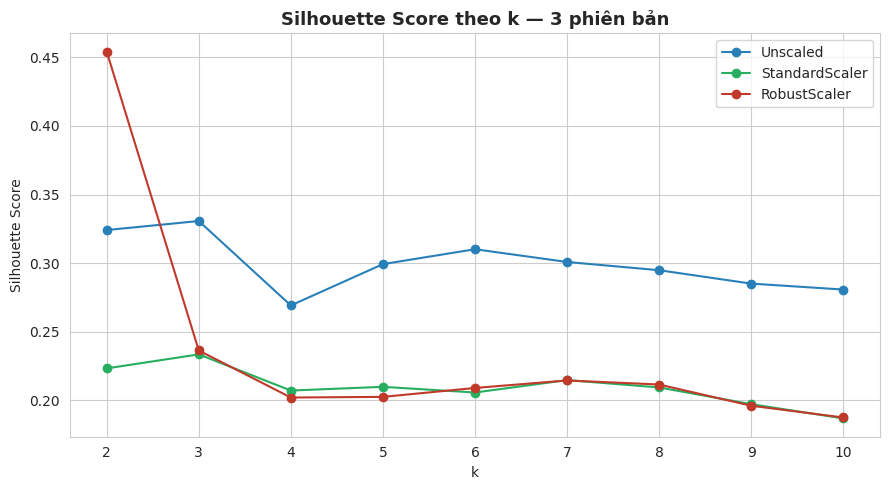

In [48]:
fig, ax = plt.subplots(figsize=(9, 5))
for name, vals in silhouette_results.items():
    ax.plot(K_RANGE, vals, marker="o", label=name, color=colors[name])
ax.set_xlabel("k")
ax.set_ylabel("Silhouette Score")
ax.set_title("Silhouette Score theo k — 3 phiên bản")
ax.legend()
plt.tight_layout()
plt.show()


**Kết quả:** `Unscaled` và `StandardScaler` đều đề xuất k=3, còn `RobustScaler` đề xuất k=2 với silhouette nổi bật hẳn (≈0.45, cao hơn rõ rệt so với các k khác của chính nó) — gợi ý RobustScaler nhìn thấy 1 ranh giới rất rõ chia dữ liệu thành 2 nhóm lớn (nhiều khả năng là "cầu thủ thiên phòng ngự" vs "cầu thủ thiên tấn công", vì đây luôn là trục phân tách mạnh nhất trong bóng đá). Như đã lưu ý ở bài Shot Zone: **không so sánh giá trị Silhouette tuyệt đối giữa các phiên bản** vì mỗi phiên bản sống trong 1 không gian metric khác nhau — chỉ dùng để chọn k trong nội bộ từng phiên bản.

## 5.3 — Gap Statistic (song song 3 phiên bản)

In [49]:
def compute_gap_statistic(X, k_range, B=10, random_state=42):
    rng = np.random.default_rng(random_state)
    mins, maxs = X.min(axis=0), X.max(axis=0)

    def fit_inertia(data, k, seed):
        km = KMeans(n_clusters=k, n_init=10, random_state=seed)
        km.fit(data)
        return km.inertia_

    gaps, sks = [], []
    for k in k_range:
        wk_real = fit_inertia(X, k, random_state)
        log_wk_refs = []
        for b in range(B):
            X_ref = rng.uniform(low=mins, high=maxs, size=X.shape)
            wk_ref = fit_inertia(X_ref, k, random_state + b + 1)
            log_wk_refs.append(np.log(wk_ref))
        log_wk_refs = np.array(log_wk_refs)
        gap = log_wk_refs.mean() - np.log(wk_real)
        sk = log_wk_refs.std() * np.sqrt(1 + 1.0 / B)
        gaps.append(gap)
        sks.append(sk)
    return np.array(gaps), np.array(sks)


def choose_k_tibshirani(k_range, gaps, sks):
    for i in range(len(k_range) - 1):
        if gaps[i] >= gaps[i + 1] - sks[i + 1]:
            return k_range[i]
    return None


In [50]:
gap_results = {}
for name, X in X_versions.items():
    gaps, sks = compute_gap_statistic(X, K_RANGE, B=10, random_state=42)
    gap_results[name] = (gaps, sks)

gap_k = {name: choose_k_tibshirani(K_RANGE, gaps, sks) for name, (gaps, sks) in gap_results.items()}
print("k chọn theo Gap Statistic:", gap_k)


k chọn theo Gap Statistic: {'Unscaled': None, 'StandardScaler': None, 'RobustScaler': None}


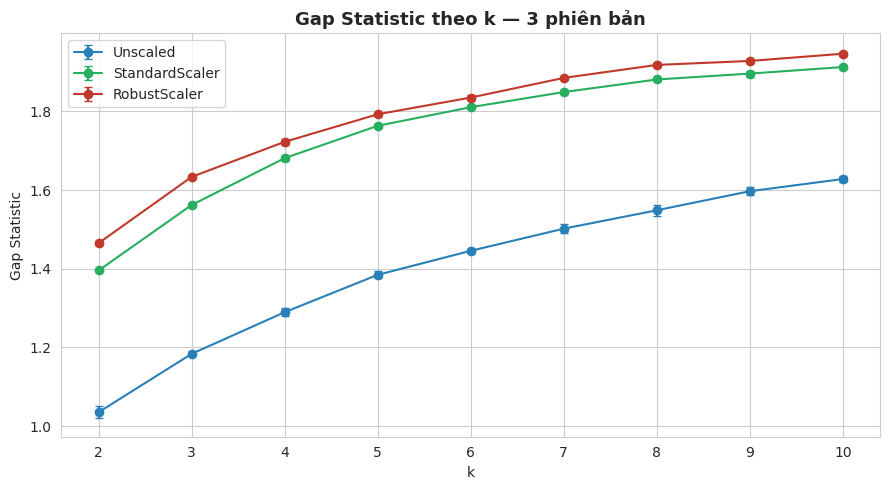

In [51]:
fig, ax = plt.subplots(figsize=(9, 5))
for name, (gaps, sks) in gap_results.items():
    ax.errorbar(K_RANGE, gaps, yerr=sks, marker="o", capsize=3, label=name, color=colors[name])
ax.set_xlabel("k")
ax.set_ylabel("Gap Statistic")
ax.set_title("Gap Statistic theo k — 3 phiên bản")
ax.legend()
plt.tight_layout()
plt.show()


**Khác biệt quan trọng so với bài Shot Zone:** ở cả 3 phiên bản, Gap Statistic **tăng liên tục suốt k=2→10 mà không hội tụ** theo quy tắc Tibshirani (trả về `None` cho cả 3, khác với bài Shot Zone nơi Unscaled/RobustScaler hội tụ ở k=2). Nhiều khả năng đây là hệ quả của **số chiều dữ liệu cao hơn** (29 feature so với 9 feature ở bài shot) — Gap Statistic so sánh dữ liệu thật với dữ liệu ngẫu nhiên đều (uniform) trong cùng không gian, và trong không gian nhiều chiều, ranh giới giữa "có cấu trúc cụm" và "ngẫu nhiên" trở nên mờ nhạt hơn (một biểu hiện thường gặp của "curse of dimensionality" lên phương pháp Gap Statistic). Đây là lý do thực tế vì sao không nên chỉ dựa vào 1 phương pháp chọn k duy nhất.

## 5.4 — Bảng tổng hợp k đề xuất

In [52]:
summary_k = pd.DataFrame({
    "Elbow (kneedle)": elbow_k,
    "Silhouette (max)": best_k_silhouette,
    "Gap Statistic (Tibshirani)": gap_k,
})
summary_k


,Elbow (kneedle),Silhouette (max),Gap Statistic (Tibshirani)
Unscaled,5,3,None
StandardScaler,5,3,None
RobustScaler,5,2,None


## 5.5 — So sánh cấu trúc cụm giữa 3 phiên bản bằng ARI

In [53]:
ari_k_range = [2, 3, 4, 5, 6]
ari_rows = []
cluster_labels_by_k = {}

for k in ari_k_range:
    labels = {}
    for name, X in X_versions.items():
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        labels[name] = km.fit_predict(X)
    cluster_labels_by_k[k] = labels

    ari_us = adjusted_rand_score(labels["Unscaled"], labels["StandardScaler"])
    ari_ur = adjusted_rand_score(labels["Unscaled"], labels["RobustScaler"])
    ari_sr = adjusted_rand_score(labels["StandardScaler"], labels["RobustScaler"])

    ari_rows.append({
        "k": k,
        "ARI(Unscaled, StandardScaler)": ari_us,
        "ARI(Unscaled, RobustScaler)": ari_ur,
        "ARI(StandardScaler, RobustScaler)": ari_sr,
    })

ari_df = pd.DataFrame(ari_rows).set_index("k")
ari_df


,"ARI(Unscaled, StandardScaler)","ARI(Unscaled, RobustScaler)","ARI(StandardScaler, RobustScaler)"
k,,,
2,0.084,0.005,0.251
3,0.092,0.087,0.931
4,0.146,0.146,0.933
5,0.296,0.292,0.930
6,0.285,0.337,0.721


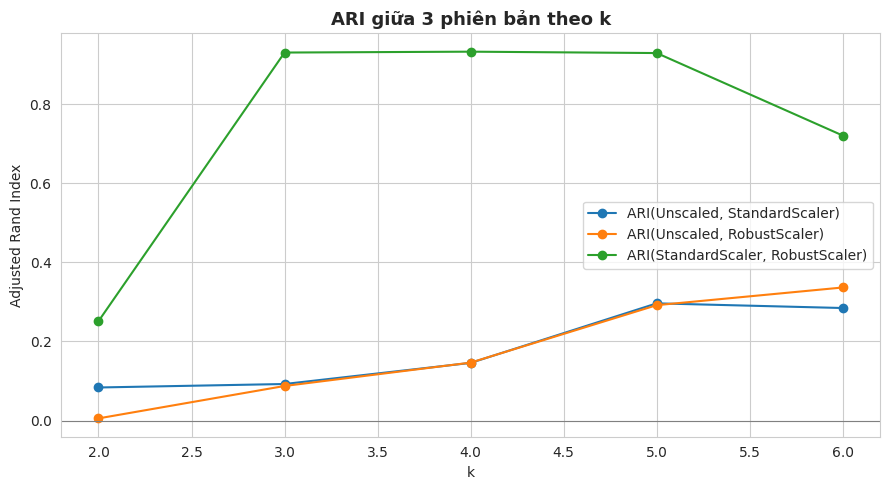

In [54]:
fig, ax = plt.subplots(figsize=(9, 5))
for col in ari_df.columns:
    ax.plot(ari_df.index, ari_df[col], marker="o", label=col)
ax.set_xlabel("k")
ax.set_ylabel("Adjusted Rand Index")
ax.set_title("ARI giữa 3 phiên bản theo k")
ax.axhline(0, color="gray", linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()


**Phát hiện quan trọng nhất của Task 5:**

- `ARI(StandardScaler, RobustScaler)` đạt mức **rất cao (~0.93)** xuyên suốt k=3,4,5 — mạnh hơn hẳn mức hội tụ ~0.65 quan sát được ở bài Shot Zone. Ở k=6, mức đồng thuận giảm nhẹ còn ~0.72 nhưng vẫn cao.
- `ARI(Unscaled, StandardScaler)` và `ARI(Unscaled, RobustScaler)` **luôn thấp** (0.08-0.34) ở mọi k — Unscaled tiếp tục cho ra cấu trúc cụm khác biệt hẳn so với cả 2 phiên bản đã scale, đúng như phát hiện ở bài Shot Zone.
- Điểm mới: tại **k=2**, `ARI(StandardScaler, RobustScaler)` bất ngờ khá thấp (0.251) dù đây là k mà RobustScaler tự "thích nhất" theo Silhouette — cho thấy ngay cả 2 phiên bản đã scale cũng không phải lúc nào cũng đồng thuận ở mọi k, sự đồng thuận mạnh chỉ rõ ràng trong vùng k=3-5.

**Kết luận:** bằng chứng tiếp tục khẳng định nguyên tắc đã rút ra ở bài Shot Zone — **việc có scale hay không quan trọng hơn nhiều so với chọn scaler nào** (miễn đã scale, kết quả khá ổn định trong vùng k=3-5).

## 5.6 — Chốt phương án cho Task 6

Áp dụng đúng logic đã dùng ở bài Shot Zone: **RobustScaler + k=5**.
- k=5: được Elbow (kneedle) đồng thuận ở cả 3 phiên bản, đồng thời nằm trong vùng k mà StandardScaler/RobustScaler hội tụ mạnh nhất (ARI≈0.93).
- RobustScaler: tiếp tục là lựa chọn nhất quán với quyết định ở Task 4 (dù Task 4 cũng cho thấy RobustScaler không phải lúc nào cũng "hiền" hơn tuyệt đối, nhưng ARI ở đây cho thấy 2 scaler cho kết quả gần như nhau ở k=5 nên lựa chọn giữa 2 scaler không ảnh hưởng nhiều).

In [55]:
FINAL_SCALER = "RobustScaler"
FINAL_K = 5

final_km = KMeans(n_clusters=FINAL_K, n_init=10, random_state=42)
final_labels = final_km.fit_predict(X_versions[FINAL_SCALER])

cluster_output = id_df.copy()
cluster_output["cluster_id"] = final_labels

for name in X_versions:
    cluster_output[f"cluster_id_{name}"] = cluster_labels_by_k[FINAL_K][name]

cluster_output.to_csv(f"{DATA_DIR}/player_clusters_k5.csv", index=False, encoding="utf-8-sig")
print(f"Đã lưu: {DATA_DIR}/player_clusters_k5.csv")
cluster_output.head(5)


Đã lưu: /kaggle/working/player_clusters_k5.csv


,player_id,player_name,primary_team,competitions_played,n_matches_played,total_minutes_played,cluster_id,cluster_id_Unscaled,cluster_id_StandardScaler,cluster_id_RobustScaler
0,3339,Asmir Begović,Chelsea,Premier League,17,1472.000,2,2,4,2
1,5594,Branislav Ivanović,Chelsea,Premier League,33,3057.000,4,0,0,4
2,3456,Kurt Happy Zouma,Chelsea,Premier League,23,2013.000,0,1,1,0
3,3645,Gary Cahill,Chelsea,Premier League,23,2061.000,0,1,1,0
4,3957,César Azpilicueta Tanco,Chelsea,Premier League,37,3351.000,4,0,0,4


In [56]:
cluster_output["cluster_id"].value_counts().sort_index()


cluster_id
0    194
1    152
2     73
3    198
4    399
Name: count, dtype: int64

## Kết quả Task 5 (Player Style)

File `player_clusters_k5.csv` chứa `cluster_id` chính thức (RobustScaler, k=5) kèm nhãn cụm tham khảo của cả 3 phiên bản, sẵn sàng cho **Task 6** — validate bằng `primary_position` đã giấu ở `player_y_hidden.csv`, và huấn luyện KNN + Cross-Validation.


## 5.7 — Trực quan hóa cụm bằng hình ảnh

Mục tiêu: trả lời "5 cụm phong cách cầu thủ này là gì" bằng hình ảnh thay vì chỉ nhìn bảng số. Gồm 3 phần:

1. **PCA 2D** — chiếu 29 feature xuống 2 trục chính để xem cụm tách biệt/chồng lấn ra sao (giống phương pháp đã dùng ở bài Shot Zone).
2. **Kích thước từng cụm** — số cầu thủ mỗi cụm, cần biết trước khi diễn giải (cụm nhỏ có thể là nhóm đặc thù/hiếm).
3. **Hồ sơ đặc trưng (feature profile heatmap)** — giá trị trung bình từng feature theo từng cụm, chuẩn hoá z-score để so sánh công bằng giữa các feature có thang đo khác nhau.

Lưu ý về màu: với 5 cụm hiển thị đồng thời trên 1 biểu đồ scatter, 2 trong 5 màu (vàng/magenta) có thể khó phân biệt với người mù màu nếu chỉ dựa vào màu — nên ngoài biểu đồ tổng quan (màu + hình dạng marker khác nhau), notebook có thêm bản "tách từng cụm" (facet) để đảm bảo mọi cụm đều dễ phân biệt.

In [ ]:
from sklearn.decomposition import PCA

# Palette cố định theo thứ tự categorical, dùng xuyên suốt mọi biểu đồ ở mục 5.7
CLUSTER_COLORS = {
    0: "#2a78d6",  # blue
    1: "#eb6834",  # orange
    2: "#1baf7a",  # aqua
    3: "#eda100",  # yellow
    4: "#e87ba4",  # magenta
}
CLUSTER_MARKERS = {0: "o", 1: "s", 2: "^", 3: "D", 4: "v"}

GRID_COLOR = "#e1e0d9"
MUTED_INK = "#898781"
SECONDARY_INK = "#52514e"


def _style_axes(ax):
    ax.grid(True, color=GRID_COLOR, linewidth=0.8)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color(MUTED_INK)
    ax.tick_params(colors=SECONDARY_INK)


pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_versions[FINAL_SCALER])
evr = pca.explained_variance_ratio_

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["cluster"] = final_labels

fig, ax = plt.subplots(figsize=(7, 6))
for c in sorted(pca_df["cluster"].unique()):
    sub = pca_df[pca_df["cluster"] == c]
    ax.scatter(
        sub["PC1"], sub["PC2"],
        s=28, alpha=0.75, linewidths=0,
        color=CLUSTER_COLORS[c], marker=CLUSTER_MARKERS[c],
        label=f"Cluster {c} (n={len(sub)})",
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"PCA 2D — {FINAL_SCALER}, k={FINAL_K}\nPC1+PC2 giai thich {evr.sum():.1%} phuong sai")
_style_axes(ax)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8), sharex=True, sharey=True)
axes = axes.ravel()

for i, c in enumerate(sorted(pca_df["cluster"].unique())):
    ax = axes[i]
    other = pca_df[pca_df["cluster"] != c]
    sub = pca_df[pca_df["cluster"] == c]
    ax.scatter(other["PC1"], other["PC2"], s=14, color=MUTED_INK, alpha=0.25, linewidths=0)
    ax.scatter(
        sub["PC1"], sub["PC2"],
        s=22, color=CLUSTER_COLORS[c], marker=CLUSTER_MARKERS[c],
        alpha=0.85, linewidths=0,
    )
    ax.set_title(f"Cluster {c} (n={len(sub)})", fontsize=10, color=SECONDARY_INK)
    _style_axes(ax)
    ax.tick_params(labelsize=8)

# 6 o cho 5 cum -> an o thua
axes[5].axis("off")

fig.suptitle(
    "Từng cụm tách riêng trên cùng nền PCA (bản dễ phân biệt, không phụ thuộc màu sắc)",
    y=1.02,
)
plt.tight_layout()
plt.show()


In [ ]:
cluster_sizes = cluster_output["cluster_id"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(
    cluster_sizes.index.astype(str), cluster_sizes.values,
    color=[CLUSTER_COLORS[c] for c in cluster_sizes.index],
    width=0.6,
)
for rect, val in zip(bars, cluster_sizes.values):
    ax.text(
        rect.get_x() + rect.get_width() / 2, rect.get_height() + 6, str(val),
        ha="center", va="bottom", fontsize=9, color=SECONDARY_INK,
    )

ax.set_xlabel("Cluster")
ax.set_ylabel("So cau thu")
ax.set_title(f"Kich thuoc tung cum ({FINAL_SCALER}, k={FINAL_K}, tong {cluster_sizes.sum()} cau thu)")
ax.grid(True, axis="y", color=GRID_COLOR, linewidth=0.8)
ax.set_axisbelow(True)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):
    ax.spines[spine].set_color(MUTED_INK)
ax.tick_params(colors=SECONDARY_INK)
plt.tight_layout()
plt.show()


### Hồ sơ đặc trưng từng cụm (feature profile heatmap)

Tính giá trị trung bình **chưa scale** của cả 29 feature theo từng cụm (dễ đọc bằng đơn vị gốc — vd. bàn/90 phút — hơn là dùng giá trị đã qua RobustScaler), sau đó chuẩn hoá theo từng feature (z-score qua 5 cụm) chỉ để tô màu heatmap cho công bằng giữa các feature có thang đo khác nhau (vd. `shots_p90` ~0-5 vs `passes_p90` ~0-80). Màu đỏ = cụm đó cao hơn trung bình các cụm khác ở feature đó, xanh = thấp hơn. Bảng giá trị thật (chưa chuẩn hoá) được in ra ngay trước heatmap để đối chiếu số liệu gốc.

In [ ]:
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap

raw_features_df = raw_frames["Unscaled"][FEATURE_COLS].copy()
raw_features_df["cluster"] = final_labels

centroid_raw = raw_features_df.groupby("cluster")[FEATURE_COLS].mean()

# Z-score theo TUNG COT (qua 5 cum) - chi dung de to mau heatmap, khong dung de doc so lieu
centroid_z = (centroid_raw - centroid_raw.mean(axis=0)) / centroid_raw.std(axis=0)

print("Gia tri trung binh that (chua chuan hoa) theo tung cum:")
display(centroid_raw.round(2))

diverging_cmap = LinearSegmentedColormap.from_list("blue_gray_red", ["#1c5cab", "#f0efec", "#e34948"])

fig, ax = plt.subplots(figsize=(7, 11))
sns.heatmap(
    centroid_z.T, cmap=diverging_cmap, center=0, vmin=-2.5, vmax=2.5,
    linewidths=0.5, linecolor="#fcfcfb",
    cbar_kws={"label": "Z-score (so voi trung binh cac cum)"},
    ax=ax,
)
ax.set_xlabel("Cluster")
ax.set_ylabel("")
ax.set_title(f"Ho so dac trung tung cum ({FINAL_SCALER}, k={FINAL_K})\n(do = cao hon TB cac cum, xanh = thap hon)")
plt.tight_layout()
plt.show()


### Cách đọc kết quả mục 5.7

- **PCA tổng quan**: nếu 5 màu tách thành vùng riêng biệt → cấu trúc cụm rõ ràng; nếu chồng lấn nhiều ở vùng trung tâm → các phong cách gần nhau tạo thành một continuum (giống phát hiện đã có ở bài Shot Zone khi bỏ `body_part`).
- **Bản tách từng cụm**: dùng khi khó phân biệt 5 màu cùng lúc — xem từng cụm chiếm vùng nào trên nền PCA mà không bị 4 cụm còn lại gây rối mắt.
- **Kích thước cụm**: cụm chiếm đa số nhiều khả năng là nhóm "phong cách phổ biến" (vd. tiền vệ/hậu vệ tham gia phòng ngự cơ bản), cụm nhỏ có thể là nhóm đặc thù/hiếm (vd. tiền đạo ghi bàn cao, chuyên gia tạt cánh) — cần biết tỉ lệ này trước khi diễn giải centroid.
- **Heatmap hồ sơ đặc trưng**: đọc theo hàng (feature) — cụm nào đỏ đậm nhất ở `np_goals_p90`/`shots_p90` nhiều khả năng là cụm tiền đạo; đỏ đậm ở `tackles_p90`/`interceptions_p90`/`clearances_p90` là cụm thiên phòng ngự; đỏ đậm ở `key_passes_p90`/`through_balls_p90`/`crosses_p90` là cụm kiến tạo. Đối chiếu với bảng `centroid_raw` (giá trị thật) để có con số cụ thể khi viết kết luận, không chỉ dựa vào màu.

## 5.8 — Danh sách cầu thủ tiêu biểu từng cụm

Để đối chiếu cụm với thực tế (cụm này có đúng là "tiền đạo ghi bàn cao" như heatmap gợi ý không), liệt kê top cầu thủ **gần tâm cụm (centroid) nhất** trong không gian feature đã dùng để phân cụm (`FINAL_SCALER`) — đây là những cầu thủ "điển hình" nhất của cụm, dễ nhận diện tên tuổi hơn lấy ngẫu nhiên. Kèm vài chỉ số chính (bàn/90p, sút/90p, chuyền quan trọng/90p, tắc bóng/90p, tranh chấp bổng/90p) để kiểm tra nhanh ngay trong bảng, không cần quay lại heatmap.

Muốn xem toàn bộ danh sách đầy đủ của 1 cụm (không chỉ top N), lọc trực tiếp `cluster_output[cluster_output["cluster_id"] == <id>]`.

In [ ]:
from IPython.display import display

N_REPRESENTATIVE = 10

feature_matrix = X_versions[FINAL_SCALER]
centers = final_km.cluster_centers_
dist_to_centroid = np.linalg.norm(feature_matrix - centers[final_labels], axis=1)

listing_df = id_df.copy()
listing_df["cluster_id"] = final_labels
listing_df["dist_to_centroid"] = dist_to_centroid

key_stats = raw_frames["Unscaled"][[
    "player_id", "np_goals_p90", "shots_p90", "key_passes_p90",
    "tackles_p90", "interceptions_p90", "aerial_won_p90",
]]
listing_df = listing_df.merge(key_stats, on="player_id", how="left")

display_cols = [
    "player_name", "primary_team", "n_matches_played", "total_minutes_played",
    "np_goals_p90", "shots_p90", "key_passes_p90", "tackles_p90",
    "interceptions_p90", "aerial_won_p90",
]

for c in sorted(listing_df["cluster_id"].unique()):
    sub = (
        listing_df[listing_df["cluster_id"] == c]
        .sort_values("dist_to_centroid")
        .head(N_REPRESENTATIVE)
    )
    print(f"\n=== Cluster {c} (n={cluster_sizes[c]}) - {len(sub)} cau thu gan centroid nhat ===")
    display(sub[display_cols].reset_index(drop=True).round(2))
